<a href="https://colab.research.google.com/github/Divya-Apotikar08/Spam-Mail-Prediction/blob/main/Spam_Mail_Prediction_using_Machine_Lerning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing the dependencies

In [8]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


Data Collection & Pre-Processing

In [11]:
# loading the data from csv file to a pandas Dataframe
raw_mail_data = pd.read_csv('/content/Maildata.csv')

In [12]:
print(raw_mail_data)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5695      ham  I want to send something that can sell fast.  ...
5696      ham  Haha good to hear, I'm officially paid and on ...
5697      ham  Yes I started to send requests to make it but ...
5698      ham  have got * few things to do. may be in * pub l...
5699      ham           What???? Hello wats talks email address?

[5700 rows x 2 columns]


In [13]:
# replace the null values with a null string
mail_data = raw_mail_data.where((pd.notnull(raw_mail_data)),'')

In [14]:
# printing the first 5 rows of the dataframe
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
# checking the number of rows and columns in the dataframe
mail_data.shape

(5700, 2)

Label Encoding

In [16]:
# label spam mail as 0;  ham mail as 1;

mail_data.loc[mail_data['Category'] == 'spam', 'Category',] = 0
mail_data.loc[mail_data['Category'] == 'ham', 'Category',] = 1

spam - 0

ham - 1

In [17]:
# separating the data as texts and label

X = mail_data['Message']

Y = mail_data['Category']

In [18]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5695    I want to send something that can sell fast.  ...
5696    Haha good to hear, I'm officially paid and on ...
5697    Yes I started to send requests to make it but ...
5698    have got * few things to do. may be in * pub l...
5699             What???? Hello wats talks email address?
Name: Message, Length: 5700, dtype: object


In [19]:
print(Y)

0       1
1       1
2       0
3       1
4       1
       ..
5695    1
5696    1
5697    1
5698    1
5699    1
Name: Category, Length: 5700, dtype: object


Splitting the data into training data & test data

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3)

In [21]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(5700,)
(4560,)
(1140,)


Feature Extraction

In [22]:
feature_extraction = TfidfVectorizer(min_df = 1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

# convert Y_train and Y_test values as integers

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

In [23]:
print(X_train)

1627                            Dear how you. Are you ok?
1203    Me also da, i feel yesterday night  wait til 2...
2237    Pls tell nelson that the bb's are no longer co...
5444    Good morning. At the repair shop--the ONLY rea...
2199                       I'm in a movie. Call me 4 wat?
                              ...                        
789     5 Free Top Polyphonic Tones call 087018728737,...
968     What do u want when i come back?.a beautiful n...
1667    Guess who spent all last night phasing in and ...
3321    Eh sorry leh... I din c ur msg. Not sad alread...
1688    Free Top ringtone -sub to weekly ringtone-get ...
Name: Message, Length: 4560, dtype: object


In [24]:
print(X_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 35396 stored elements and shape (4560, 7476)>
  Coords	Values
  (0, 2132)	0.7769602715394734
  (0, 4769)	0.6295496298539995
  (1, 2132)	0.27095970703075556
  (1, 2084)	0.25726643912037084
  (1, 2732)	0.3041528548598799
  (1, 7429)	0.349423343627004
  (1, 4639)	0.5312546257345825
  (1, 7109)	0.29571127085621757
  (1, 6678)	0.35209518568342746
  (1, 387)	0.390053241776047
  (2, 5092)	0.22876093637770287
  (2, 6554)	0.2185248918674338
  (2, 4606)	0.4046408873961959
  (2, 1226)	0.3300608142889523
  (2, 4071)	0.3404011090228165
  (2, 1857)	0.3300608142889523
  (2, 4440)	0.25737239994790456
  (2, 2644)	0.362180703475642
  (2, 882)	0.37252099820950624
  (2, 1858)	0.25737239994790456
  (3, 3096)	0.2678681388072632
  (3, 4457)	0.34075664958620505
  (3, 5538)	0.5371612992398288
  (3, 5929)	0.41162903304690057
  (3, 5442)	0.4425666873880448
  :	:
  (4557, 2879)	0.4733116064506164
  (4557, 2265)	0.4733116064506164
  (4558, 3899)	0.30916

Training the Model

Logistic Regression

In [25]:
model = LogisticRegression()

In [26]:
# training the Logistic Regression model with the training data
model.fit(X_train_features, Y_train)

LogisticRegression()

Evaluating the trained model

In [27]:
# prediction on training data

prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data)

In [28]:
print('Accuracy on training data : ', accuracy_on_training_data)

Accuracy on training data :  0.9631578947368421


In [29]:
# prediction on test data

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(Y_test, prediction_on_test_data)

In [30]:
print('Accuracy on test data : ', accuracy_on_test_data)

Accuracy on test data :  0.9543859649122807


Building a Predictive System

In [31]:
input_mail = ["I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times"]

# convert text to feature vectors
input_data_features = feature_extraction.transform(input_mail)

# making prediction

prediction = model.predict(input_data_features)
print(prediction)


if (prediction[0]==1):
  print('Ham mail')

else:
  print('Spam mail')

[1]
Ham mail


In [35]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test, prediction_on_test_data))
print(confusion_matrix(Y_test, prediction_on_test_data))

              precision    recall  f1-score   support

           0       0.96      0.70      0.81       159
           1       0.95      0.99      0.97       981

    accuracy                           0.95      1140
   macro avg       0.96      0.85      0.89      1140
weighted avg       0.95      0.95      0.95      1140

[[112  47]
 [  5 976]]


Spam vs Ham Distribution Graph

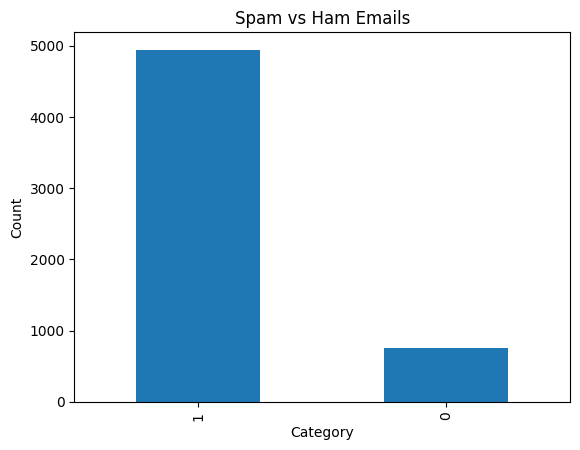

In [36]:
import matplotlib.pyplot as plt

mail_data['Category'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Emails')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

Confusion Matrix Heatmap

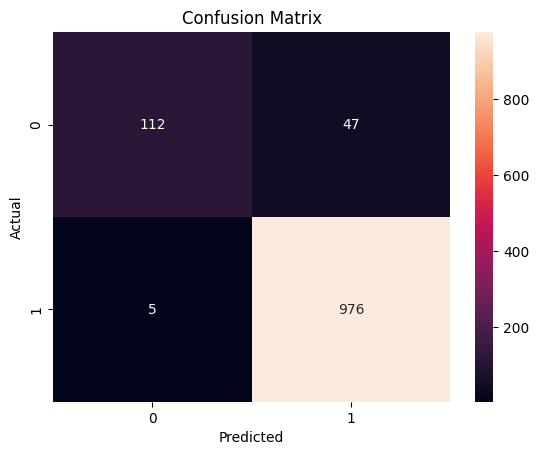

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, prediction_on_test_data)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy Comparison (if you try multiple models)

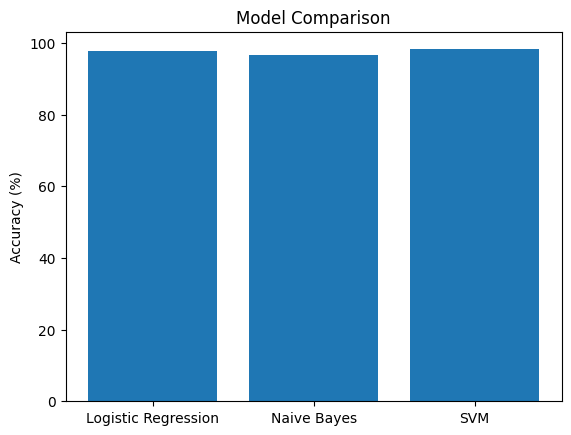

In [38]:
models = ['Logistic Regression', 'Naive Bayes', 'SVM']
accuracy = [97.8, 96.5, 98.2]

plt.bar(models, accuracy)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.show()

Classification Report

In [39]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, prediction_on_test_data))

              precision    recall  f1-score   support

           0       0.96      0.70      0.81       159
           1       0.95      0.99      0.97       981

    accuracy                           0.95      1140
   macro avg       0.96      0.85      0.89      1140
weighted avg       0.95      0.95      0.95      1140

